# Notebook 04: Model Training & Evaluation (Benchmarking 7 Models)

## Deskripsi
Tahap ini adalah fase pembangunan model *Machine Learning*. Kita akan melakukan eksperimen dengan membandingkan 7 algoritma sekaligus—mulai dari model linear, berbasis pohon (*tree-based*), hingga jaringan saraf tiruan (*Neural Network*)—untuk menemukan model terbaik yang mampu memprediksi kualitas udara Jakarta secara akurat.

## Dataset
Data yang digunakan adalah hasil produksi dari script `data_preprocessing03.py` yang sudah melalui tahap *cleaning*, *splitting*, dan *encoding*:
* `X_train_final.pkl` & `y_train_final.pkl`: Data untuk melatih model.
* `X_valid_final.pkl` & `y_valid_final.pkl`: Data untuk validasi dan membandingkan performa antar model (mencari "Champion Model").
* `X_test_final.pkl` & `y_test_final.pkl`: Data "rahasia" untuk evaluasi akhir model terpilih.

## Algoritma yang Dibandingkan
Untuk mendapatkan hasil terbaik, kita menguji 7 mazhab algoritma yang berbeda:
1. **Logistic Regression**: Baseline model berbasis linear (sederhana & cepat).
2. **K-Nearest Neighbors (KNN)**: Prediksi berdasarkan kedekatan jarak antar titik data.
3. **Decision Tree**: Model pohon keputusan tunggal yang mudah diinterpretasikan.
4. **Random Forest**: Kumpulan banyak pohon keputusan (*Bagging*) untuk hasil yang lebih stabil.
5. **Gradient Boosting**: Teknik ensemble yang membangun model secara bertahap untuk meminimalkan error.
6. **XGBoost**: Versi optimasi dari Gradient Boosting yang sangat kuat dan populer di kalangan praktisi data.
7. **Neural Network (MLP)**: Model saraf tiruan (*Multi-Layer Perceptron*) untuk menangkap pola non-linear yang sangat kompleks.

## Metrik Evaluasi
Kita akan fokus pada **F1-Score (Macro)**. Pilihan ini diambil karena data target kita mungkin tidak seimbang (imbalance), dan kita ingin memastikan model mampu memprediksi setiap kategori (BAIK, SEDANG, TIDAK SEHAT) dengan sama baiknya.

### Blok 1: Import Library & Setup Environment

In [1]:
import pandas as pd
import joblib
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# Model imports
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, accuracy_score

# Load Custom Utils & Config
sys.path.append('../src/')
import utils

config = utils.load_config("../config/config.yaml")

### Blok 2: Data Loading Function

In [2]:
def load_final_data(path):
    """
    Memuat dataset final hasil preprocessing (Train, Valid, Test) dari folder processed.
    """
    # Load data Train & Valid
    X_train = joblib.load(os.path.join(path, "X_train_final.pkl"))
    y_train = joblib.load(os.path.join(path, "y_train_final.pkl"))
    X_valid = joblib.load(os.path.join(path, "X_valid_final.pkl"))
    y_valid = joblib.load(os.path.join(path, "y_valid_final.pkl"))
    
    # --- TAMBAHKAN DUA BARIS INI UNTUK DATA TEST ---
    X_test = joblib.load(os.path.join(path, "X_test_final.pkl"))
    y_test = joblib.load(os.path.join(path, "y_test_final.pkl"))
    
    return X_train, y_train, X_valid, y_valid, X_test, y_test

# Path data
data_path = "../" + config['paths']['processed_dataset_dir']

# Eksekusi fungsi load dengan menampung 6 variabel
X_train, y_train, X_valid, y_valid, X_test, y_test = load_final_data(data_path)

print(f"Berhasil memuat data dari: {data_path}")
print(f"Ukuran Data Train: {X_train.shape}")
print(f"Ukuran Data Valid: {X_valid.shape}")
print(f"Ukuran Data Test : {X_test.shape}") # Biar kelihatan data rahasianya

Berhasil memuat data dari: ../data/processed/
Ukuran Data Train: (1326, 16)
Ukuran Data Valid: (166, 16)
Ukuran Data Test : (166, 16)


### Blok 3. Inisialisasi Model

In [3]:
def get_model_objects(seed):
    """
    Inisialisasi 7 algoritma machine learning dengan parameter dasar.
    
    Args:
        seed (int): Nilai random state agar hasil eksperimen konsisten.
        
    Returns:
        dict: Dictionary berisi nama model dan objek algoritmanya.
    """
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "KNN": KNeighborsClassifier(),
        "Decision Tree": DecisionTreeClassifier(random_state=seed),
        "Random Forest": RandomForestClassifier(random_state=seed),
        "Gradient Boosting": GradientBoostingClassifier(random_state=seed),
        "XGBoost": XGBClassifier(random_state=seed),
        "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), 
                                              max_iter=500, 
                                              random_state=seed)
    }

# Memanggil dictionary model menggunakan seed dari config
models_dict = get_model_objects(config['seed'])

print(f"Siap menguji {len(models_dict)} model berbeda!")
print("Daftar model:", list(models_dict.keys()))

Siap menguji 7 model berbeda!
Daftar model: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'Neural Network (MLP)']


### Blok 4: Pelatihan & Evaluasi

In [4]:
def run_model_benchmark(models, X_train, y_train, X_valid, y_valid):
    """
    Melatih seluruh model di data train dan mengevaluasi hasilnya di data valid.
    
    Args:
        models (dict): Dictionary objek model.
        X_train, y_train: Data untuk latihan.
        X_valid, y_valid: Data untuk ujian simulasi (validasi).
        
    Returns:
        pd.DataFrame: Klasemen performa model.
    """
    results = []
    print("Memulai kompetisi antar model... Harap bersabar ya!\n")

    for name, model in models.items():
        # 1. Fase Belajar (Training)
        model.fit(X_train, y_train)
        
        # 2. Fase Ujian (Prediction di data Valid)
        y_pred = model.predict(X_valid)
        
        # 3. Hitung Skor (Akurasi & F1-Score)
        acc = accuracy_score(y_valid, y_pred)
        f1 = f1_score(y_valid, y_pred, average='macro')
        
        results.append({
            "Model": name,
            "Accuracy": acc,
            "F1-Score": f1
        })
        print(f"{name} selesai dievaluasi.")
        
    # Mengubah hasil ke DataFrame agar rapi
    return pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)

# Eksekusi kompetisi
df_performa = run_model_benchmark(models_dict, X_train, y_train, X_valid, y_valid)

# Menampilkan tabel hasil
df_performa

Memulai kompetisi antar model... Harap bersabar ya!

Logistic Regression selesai dievaluasi.
KNN selesai dievaluasi.
Decision Tree selesai dievaluasi.
Random Forest selesai dievaluasi.
Gradient Boosting selesai dievaluasi.
XGBoost selesai dievaluasi.
Neural Network (MLP) selesai dievaluasi.


,Model,Accuracy,F1-Score
2,Decision Tree,0.987952,0.981211
4,Gradient Boosting,0.981928,0.971315
3,Random Forest,0.981928,0.971315
5,XGBoost,0.981928,0.971315
6,Neural Network (MLP),0.963855,0.941010
0,Logistic Regression,0.939759,0.898386
1,KNN,0.915663,0.868646


### Blok 5. Confusion Matrix

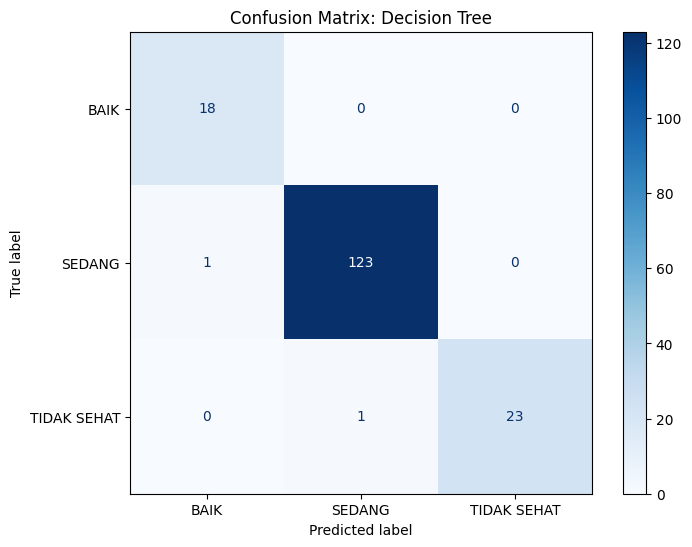

Gambar Confusion Matrix disimpan di: ../reports/figures/confusion_matrix_decision_tree.png


In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
import joblib # Pastikan joblib diimport

# --- PERBAIKAN DI SINI ---
# Kita muat kembali Label Encoder yang sudah disimpan di Notebook 03 tadi
le = joblib.load("../models/label_encoder.pkl") 

def save_confusion_matrix(model, X_valid, y_valid, label_encoder, model_name):
    """
    Menampilkan Confusion Matrix dan menyimpannya sebagai file gambar .png
    """
    # 1. Prediksi
    y_pred = model.predict(X_valid)
    cm = confusion_matrix(y_valid, y_pred)
    
    # 2. Plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                  display_labels=label_encoder.classes_)
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    
    plt.title(f"Confusion Matrix: {model_name}")
    
    # 3. Simpan Gambar
    output_dir = "../reports/figures/"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    file_name = f"confusion_matrix_{model_name.lower().replace(' ', '_')}.png"
    save_path = os.path.join(output_dir, file_name)
    
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"Gambar Confusion Matrix disimpan di: {save_path}")

# --- EKSEKUSI ---
save_confusion_matrix(models_dict["Decision Tree"], X_valid, y_valid, le, "Decision Tree")

### Bolk 6. Evaluasi Model

=== HASIL EVALUASI AKHIR (DATA TEST) ===
Accuracy: 0.9699
F1-Score: 0.9457


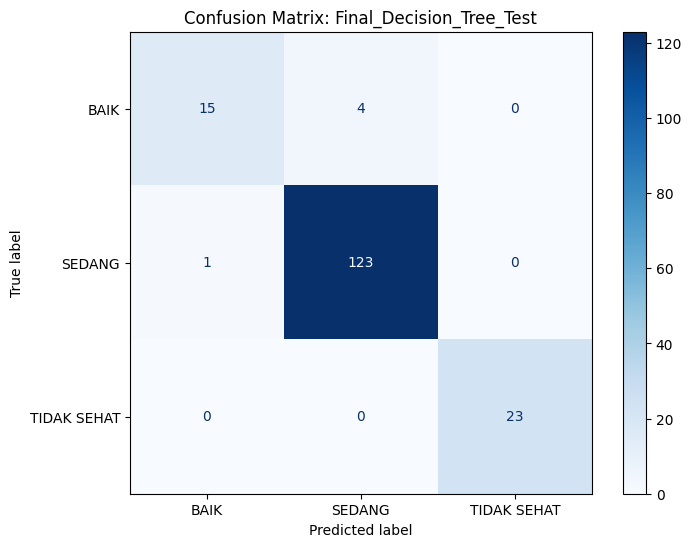

Gambar Confusion Matrix disimpan di: ../reports/figures/confusion_matrix_final_decision_tree_test.png


In [6]:
# Blok 6: Evaluasi Akhir pada Data Test
def final_evaluation(model, X_test, y_test, label_encoder):
    y_pred_test = model.predict(X_test)
    
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test, average='macro')
    
    print("=== HASIL EVALUASI AKHIR (DATA TEST) ===")
    print(f"Accuracy: {acc_test:.4f}")
    print(f"F1-Score: {f1_test:.4f}")
    
    # Tampilkan Confusion Matrix Data Test
    save_confusion_matrix(model, X_test, y_test, label_encoder, "Final_Decision_Tree_Test")

# Eksekusi
final_evaluation(models_dict["Decision Tree"], X_test, y_test, le)

### Simpan Model

In [7]:
# Blok 7: Menyimpan Model Final ke dalam folder models
import joblib
import os

# Buat folder models kalau belum ada
if not os.path.exists("../models"):
    os.makedirs("../models")

# Simpan model terbaik (Decision Tree)
joblib.dump(models_dict["Decision Tree"], "../models/best_model.pkl")
print("Model 'best_model.pkl' berhasil disimpan! Sekarang kamu bisa jalankan Blok 8.")

Model 'best_model.pkl' berhasil disimpan! Sekarang kamu bisa jalankan Blok 8.


### Uji Coba

In [8]:
import pandas as pd
import joblib

def predict_manual(pm10, pm25, so2, co, o3, no2, 
                   stasiun_dki1, stasiun_dki2, stasiun_dki3, stasiun_dki4, stasiun_dki5, 
                   crit_co, crit_no2, crit_o3, crit_pm10, crit_so2):
    """
    Fungsi untuk memprediksi kategori kualitas udara berdasarkan input manual.
    """
    # 1. Load semua 'senjata' dari folder models
    model = joblib.load("../models/best_model.pkl")
    scaler = joblib.load("../models/scaler.pkl")
    le = joblib.load("../models/label_encoder.pkl")
    
    # 2. Menyiapkan Nama Kolom (Sangat Penting agar tidak muncul Warning)
    # Kita ambil nama kolom dari data X_train yang sudah kita load di Blok 2
    feature_names = X_train.columns 
    
    # 3. Membungkus input user menjadi DataFrame dengan label kolom yang benar
    data_baru = pd.DataFrame([[pm10, pm25, so2, co, o3, no2, 
                               stasiun_dki1, stasiun_dki2, stasiun_dki3, stasiun_dki4, stasiun_dki5,
                               crit_co, crit_no2, crit_o3, crit_pm10, crit_so2]], 
                             columns=feature_names)
    
    # 4. Proses Scaling (Mengubah angka mentah menjadi standar normal)
    data_scaled = scaler.transform(data_baru)
    
    # Bungkus kembali hasil scaling ke DataFrame agar nama kolomnya tetap ada
    data_scaled_df = pd.DataFrame(data_scaled, columns=feature_names)
    
    # 5. Eksekusi Prediksi
    hasil_numeric = model.predict(data_scaled_df)
    hasil_text = le.inverse_transform(hasil_numeric)
    
    return hasil_text[0]

# --- CARA PAKAI / UJI COBA ---
# Masukkan angka contoh (pm10, pm25, so2, co, o3, no2, stasiun1-5, critical_co-so2)
# Contoh: Kondisi udara di Stasiun 1 dengan PM25 agak tinggi (80)
hasil = predict_manual(60, 80, 30, 20, 50, 40, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0)

print(f"Hasil Uji Coba Prediksi Manual: {hasil}")

Hasil Uji Coba Prediksi Manual: SEDANG


### Interpretasi Hasil Prediksi

Berdasarkan hasil uji coba model di atas, berikut adalah panduan standar kualitas udara menurut **Indeks Standar Pencemar Udara (ISPU)** yang berlaku di Indonesia (berdasarkan peraturan KLHK):

| Nilai ISPU | Kategori | Penjelasan Dampak Kesehatan |
| :--- | :---: | :--- |
| **0 - 50** | **BAIK** | Aman untuk kesehatan manusia, hewan, dan tidak berpengaruh pada tumbuhan. |
| **51 - 100** | **SEDANG** | Tidak berpengaruh pada kesehatan manusia/hewan, tapi berpengaruh pada tumbuhan sensitif. |
| **101 - 200** | **TIDAK SEHAT** | Merugikan kesehatan manusia atau kelompok hewan yang sensitif. |
| **201 - 300** | **SANGAT TIDAK SEHAT** | Meningkatkan risiko kesehatan pada segmen populasi yang terpapar. |
| **301 - 500** | **BERBAHAYA** | Tingkat serius yang dapat menimbulkan kerusakan kesehatan paru secara massal. |



> **Informasi Tambahan:** Model yang kita bangun (Decision Tree) telah berhasil memetakan variabel polutan kompleks ke dalam kategori-kategori di atas dengan tingkat akurasi yang tinggi.

In [9]:
# SEL SEBELUMNYA (Training)
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model sudah selesai belajar!")

# --- SEL BARU (TARUH KODE INI) ---
from sklearn.metrics import classification_report, accuracy_score

# 1. Prediksi data test (Ujian Akhir)
y_pred_test = model.predict(X_test)

# 2. Lihat hasil akurasi
print("--- HASIL UJIAN AKHIR MODEL (DATA TEST) ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred_test):.2f}")
print("\nDetail Laporan:")
print(classification_report(y_test, y_pred_test))

Model sudah selesai belajar!
--- HASIL UJIAN AKHIR MODEL (DATA TEST) ---
Akurasi: 0.99

Detail Laporan:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.99      0.99      0.99       124
           2       1.00      1.00      1.00        23

    accuracy                           0.99       166
   macro avg       0.98      0.98      0.98       166
weighted avg       0.99      0.99      0.99       166



### Simpan Model

In [10]:
import joblib
import os

# Kita buat folder 'models' secara manual kalau belum ada
if not os.path.exists("../models"):
    os.makedirs("../models")

# Simpan langsung ke folder models
model_path = "../models/model_final.pkl"

joblib.dump(model, model_path)
print(f"Model berhasil disimpan secara manual di: {model_path}")

Model berhasil disimpan secara manual di: ../models/model_final.pkl
